# Tracking coastal sediment flow using optical flow vectors <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment only
* **Products used:** 
[ga_s2ls_intertidal_cyear_3](https://explorer.dea.ga.gov.au/ga_s2ls_intertidal_cyear_3)

## Background

### Digital Earth Australia use case

## Description

***


## Getting started
**To run this analysis**, run all the cells in the notebook, starting with the "Load packages" cell.

**After finishing the analysis**, return to the "Analysis parameters" cell, modify some values (e.g. choose a different location or time period to analyse) and re-run the analysis.
There are additional instructions on modifying the notebook at the end.

### Load packages
Load key Python packages and supporting functions for the analysis.

In [1]:
import datacube
import sys
import cv2
import numpy as np

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import rgb, display_map
from dea_tools.temporal import xr_optical_flow
from dea_tools.dask import create_local_dask_cluster

# Create local dask cluster to improve data load time
client = create_local_dask_cluster(return_client=True)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 15,Total memory: 114.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39625,Workers: 1
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Total threads: 15
Started: Just now,Total memory: 114.00 GiB
Comm: tcp://127.0.0.1:38895,Total threads: 15
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/39879/status,Memory: 114.00 GiB
Nanny: tcp://127.0.0.1:36509,


### Connect to the datacube
Activate the datacube database, which provides functionality for loading and displaying stored Earth observation data.

In [2]:
dc = datacube.Datacube(app="Tracking_sediment_flow")

### Analysis parameters

The following cell set important parameters for the analysis:

* `lat_range`: The latitude range to analyse. 
For reasonable load times, keep this to a range of ~0.1 degrees or less.
* `lon_range`: The longitude range to analyse. 
For reasonable load times, keep this to a range of ~0.1 degrees or less.
* `time_range`: The date range to analyse.

By default, this example will track coastal sediment flow across sandy tidal flats near **Bird Island north of Adelaide, South Australia.**



<div class="alert alert-info">
    
**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

</div>

In [3]:
lat_range = (-34.745, -34.77)
lon_range = (138.47, 138.515)
time_range = ("2017", "2023")

## View the selected location
The next cell will display the selected area on an interactive map.
Feel free to zoom in and out to get a better understanding of the area you'll be analysing.
Clicking on any point of the map will reveal the latitude and longitude coordinates of that point.

In [4]:
display_map(x=lon_range, y=lat_range)


## Load DEA Intertidal data
The first step in this analysis is to load in DEA Intertidal elevation data for the `lat_range`, `lon_range` and `time_range` we provided above. 

In [5]:
# Load available data 
da = dc.load(
    product="ga_s2ls_intertidal_cyear_3",
    measurements=["elevation"],
    y=lat_range,
    x=lon_range,
    time=time_range,
).elevation

**Once the load is complete**, we can plot our data to view intertidal elevation data for our study area.
Note that to the naked eye, it can be difficult to visually see change between these timesteps.

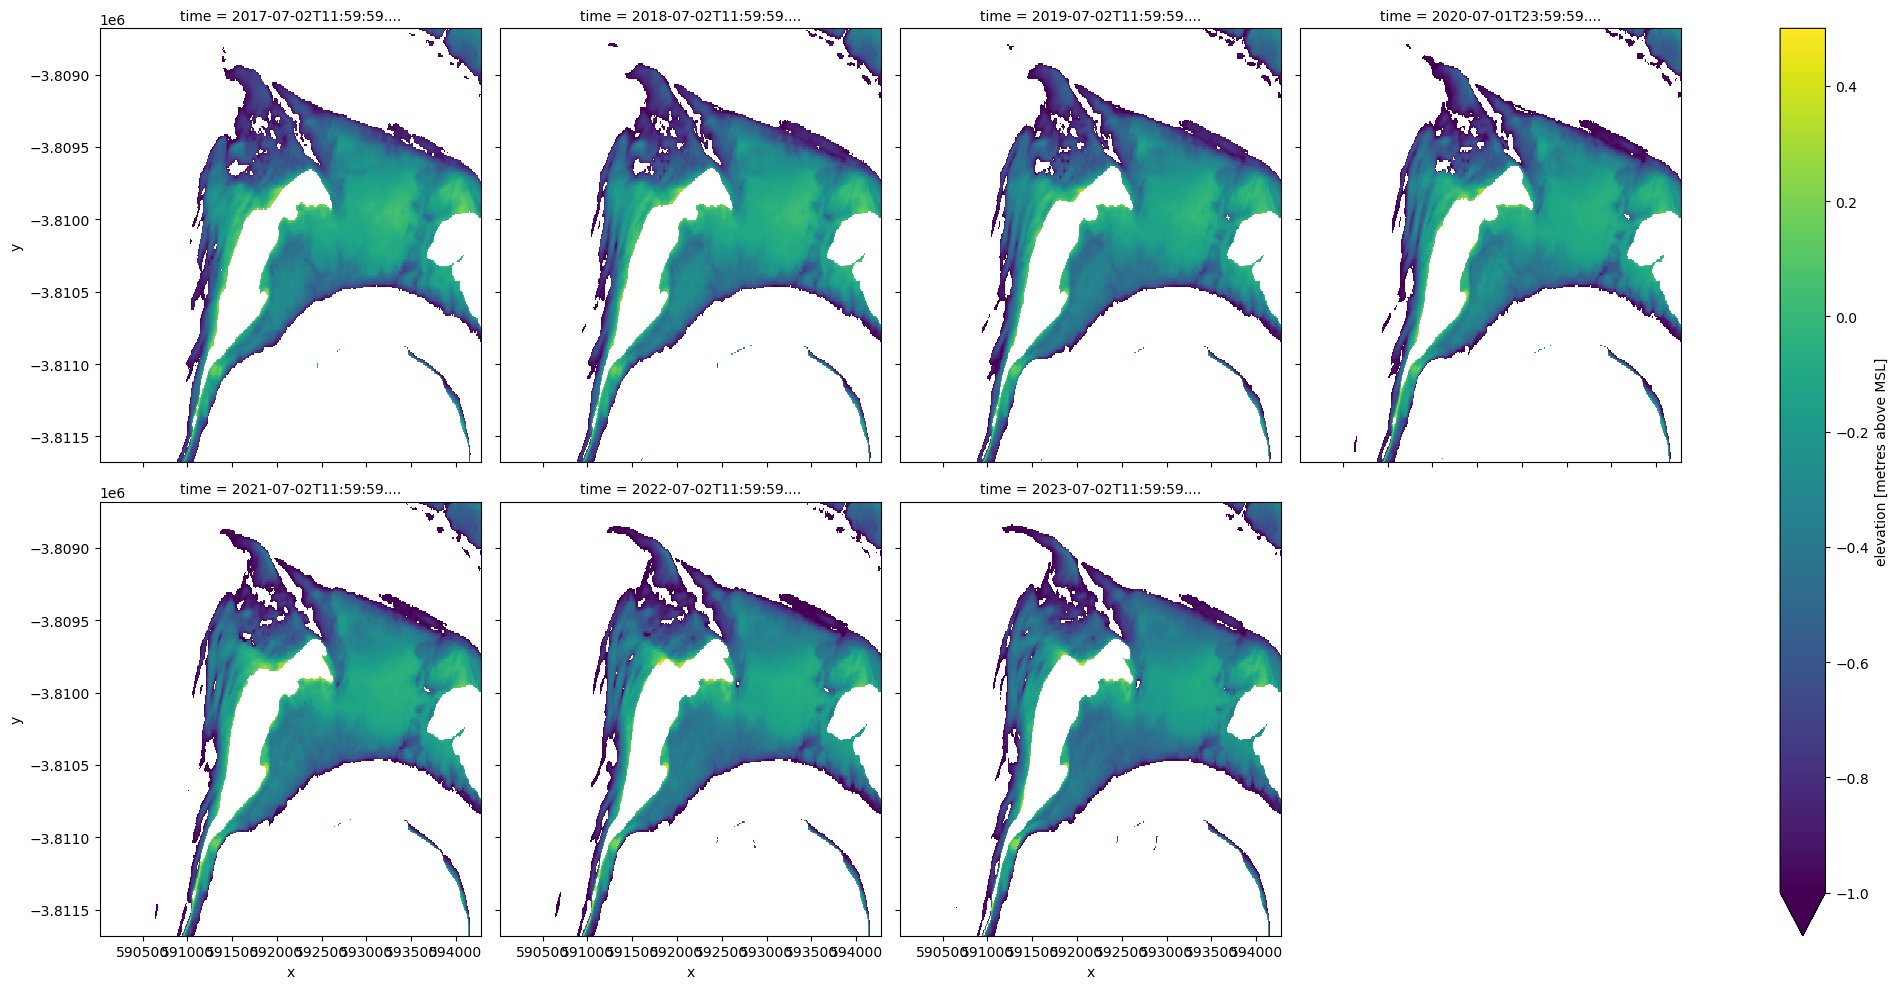

In [6]:
da.plot.imshow(col="time", cmap="viridis", col_wrap=4, vmin=-1, vmax=0.5, size=5)

## Compute elevation change over time

To get a better idea of how our coastal terrain has changed over time, we can compute the vertical difference in elevation between the first and last observation in our time-series.
In the plot below, red pixels represent locations that have lost sediment over time (e.g. erosion), and blue pixels have gained sediment (e.g. accretion):


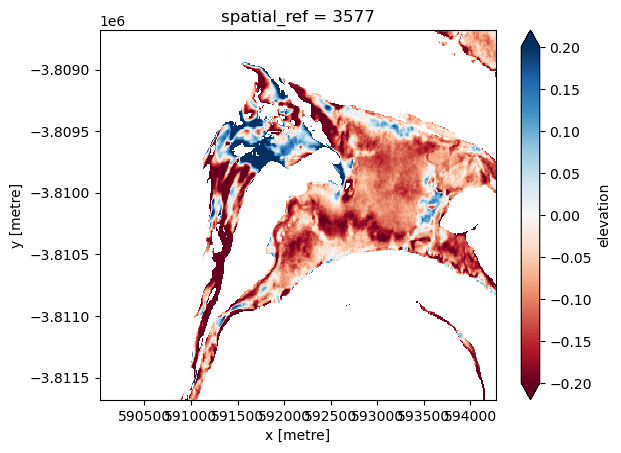

In [7]:
da_diff = da.isel(time=-1) - da.isel(time=0)
da_diff.plot.imshow(cmap="RdBu", vmin=-0.2, vmax=0.2)

## Tracking sediment movement over time

The result above only captures vertical coastal change, i.e. has a pixel gained or lost sediment. However, sediment can move laterally too, driven by coastal currents and long-shore drift.

In the following section, we use use advanced **optical flow computer vision** techniques to track the movement of sediment through the landscape over time.

### Pre-processing

Optical flow works best when an image contains visibly distinct features for the algorithm to track through time.
One approach to enhancing features in our imagery is by "sharpening" our data. 
We can achieve this using a type of spatial filter called a **high pass filter**, which will enhance sharp features, boundaries and texture in our elevation data.

In [8]:
def sharpen(da):
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])

    return xr.DataArray(cv2.filter2D(da.values, -1, kernel), coords=da.coords)


# Apply sharpening to each timestep
da_sharpened = (
    da.groupby("time").apply(lambda x: sharpen(xr.DataArray(x).squeeze()))
)

# Plot sharpened output
da_sharpened.plot.imshow(col="time", cmap="viridis", col_wrap=4, vmin=-1, vmax=0.5, size=5)

NameError: name 'xr' is not defined

### Optical flow modelling

Now that we have a sharpened timeseries, we can use the `dea_tools.temporal.xr_optical_flow` function to run our analysis.
This function will automatically iterate through our dataset, comparing each consecutive timestep and computing optical flow vectors between them.
For this reason, `xr_optical_flow` will always return one less timestep than contained in the original time series.

Note that this function does not support NaN values, so in this example we naively set these to 0 before we run the analysis.
This step however could be improved by a more robust NaN filling method.

In [ ]:
ds_flow = xr_optical_flow(da_sharpened.fillna(0))
ds_flow

The output above includes optical flow results for each pair of comparison time steps. 
To produce a single output figure that tracks sediment flow over time, we can take the median of our results, and normalise our results by the number of timesteps in our data to return rates of change per year.

In [ ]:
# Compute median flow and normalise by number of timesteps
ds_flow_median = ds_flow.median(dim="time")

For consistent comparison, we will also mask our data to only pixels that contain valid results in all of our input timesteps.

In [ ]:
valid_mask = da.notnull().all(dim="time")
ds_flow_median = ds_flow_median.where(valid_mask)

## Plotting

We can now plot our optical flow vectors.
The arrows on the map represent the flow of sediment through the landscape, with longer arrows indicating more rapid movement.

At this location, we can see the effect of long-shore sediment drift from the south, bringing sediment in a north-easterly direction around Bird Island.

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Sub-sample array for clearer quiver plot
ny, nx = ds_flow_median.u.shape
arrows_n = 50
step = max(ny // arrows_n, nx // arrows_n)
ds_sub = ds_flow_median.isel(y=slice(0, None, step), x=slice(0, None, step))

# Flip vertical axis to avoid xarray issue where negative Y
# coordinates cause vectors to be inverted
ds_sub["v"] = -ds_sub.v

# Plot background difference image
diff_ds.plot.imshow(ax=ax, cmap="RdBu", vmin=-0.2, vmax=0.2, alpha=0.7)

# Add quiver plot directly from xarray (subsampled dataset)
quiver = ds_sub.plot.quiver(
    x="x",
    y="y",
    u="u",
    v="v",
    ax=ax,
    color="black",
    angles="xy",
    scale_units="xy",
    pivot="mid",
    add_guide=False,
)

# # Add key and plot title
ax.quiverkey(quiver, 0.06, 0.97, 1, "10 m / year")
ax.set_title("Sediment flow (optical flow vectors)")
ax.set_axis_off()
fig.tight_layout()
plt.show()

## Next steps
When you are done, return to the "Set up analysis" cell, modify some values (e.g. `time_range`, `lat_range`, `lon_range`) and rerun the analysis. 

If you're going to change the location, you'll need to make sure DEA Intertidal data is available for the new location, which you can check at the [DEA Explorer](https://explorer.dea.ga.gov.au/ga_s2ls_intertidal_cyear_3).

***
## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** October 2025

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->